In [ ]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')
print("✅ All imports done!")

✅ All imports done!


In [ ]:
# Cell 2: Create synthetic resume dataset
np.random.seed(42)
n = 300

data = pd.DataFrame({
    'years_experience':   np.random.randint(0, 15, n),
    'num_skills':         np.random.randint(1, 20, n),
    'education_level':    np.random.choice([1, 2, 3], n),  # 1=diploma, 2=degree, 3=masters
    'num_projects':       np.random.randint(0, 10, n),
    'certifications':     np.random.randint(0, 5, n),
    'gap_years':          np.random.randint(0, 5, n),
    'gpa':                np.round(np.random.uniform(2.0, 4.0, n), 1),
    'github_score':       np.random.randint(0, 100, n),
    'internships':        np.random.randint(0, 4, n),
})

# Create realistic hiring label (not purely random)
score = (
    data['years_experience'] * 1 +
    data['num_skills'] * 2 +
    data['education_level'] * 1 +
    data['num_projects'] * 1 +
    data['certifications'] * 3 +
    data['github_score'] * 0.2 +
    data['gpa'] * 4 +
    data['internships'] * 1 -
    data['gap_years'] * 1
)

# Add noise
score += np.random.normal(0, 15, n)

# Hired if score above median
data['hired'] = (score > score.median()).astype(int)

print(data.shape)
print(data['hired'].value_counts())
data.head()

(300, 10)
hired
1    150
0    150
Name: count, dtype: int64


,years_experience,num_skills,education_level,num_projects,certifications,gap_years,gpa,github_score,internships,hired
0,6,17,2,7,0,2,2.4,35,1,1
1,3,6,2,5,4,3,4.0,68,2,0
2,12,5,1,9,2,4,2.7,76,3,0
3,14,2,1,6,2,4,2.4,92,3,1
4,10,6,2,7,2,2,3.6,30,3,0


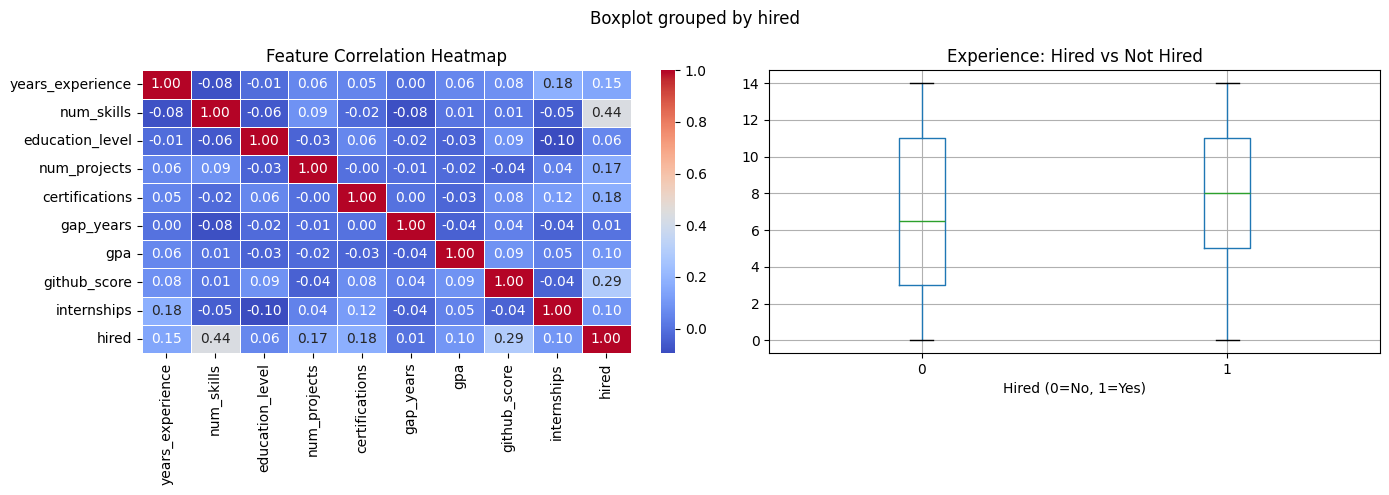

In [ ]:
# Cell 3: EDA — Correlation heatmap + boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap')

# Boxplot — experience vs hired
data.boxplot(column='years_experience', by='hired', ax=axes[1])
axes[1].set_title('Experience: Hired vs Not Hired')
axes[1].set_xlabel('Hired (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

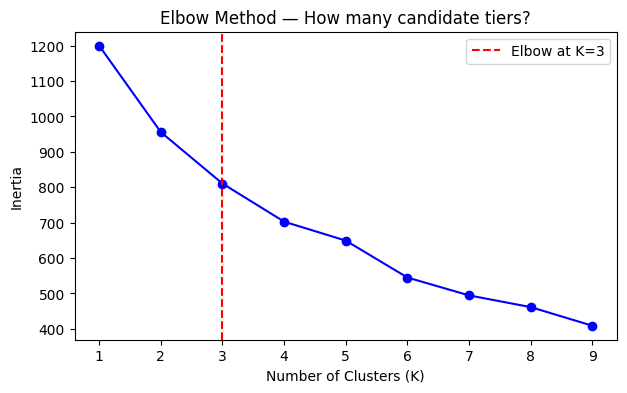

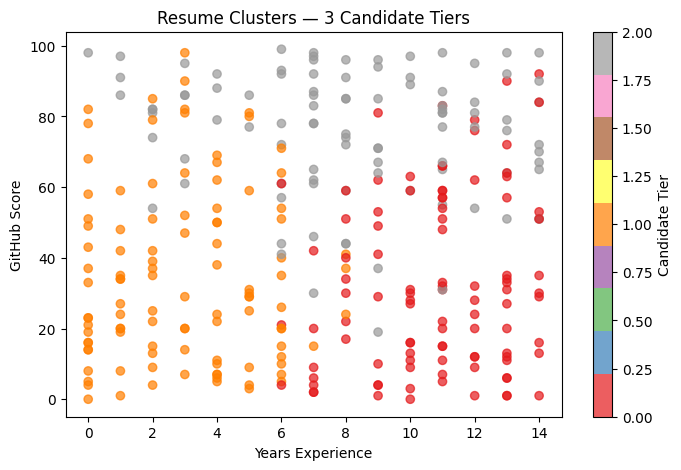

                years_experience   gpa  github_score  hired
candidate_tier                                             
0                          10.80  2.84         32.22   0.41
1                           2.96  2.83         34.35   0.40
2                           8.21  3.37         75.31   0.70


In [ ]:
# Cell 4: K-Means — group candidates into tiers
features_cluster = data[['years_experience', 'num_skills', 'gpa', 'github_score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cluster)

# Elbow method
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — How many candidate tiers?')
plt.axvline(x=3, color='red', linestyle='--', label='Elbow at K=3')
plt.legend()
plt.show()

# Final clustering with K=3
km = KMeans(n_clusters=3, random_state=42)
data['candidate_tier'] = km.fit_predict(X_scaled)

# Visualise tiers
plt.figure(figsize=(8, 5))
scatter = plt.scatter(data['years_experience'], data['github_score'],
                      c=data['candidate_tier'], cmap='Set1', alpha=0.7)
plt.colorbar(scatter, label='Candidate Tier')
plt.xlabel('Years Experience')
plt.ylabel('GitHub Score')
plt.title('Resume Clusters — 3 Candidate Tiers')
plt.show()

print(data.groupby('candidate_tier')[['years_experience','gpa','github_score','hired']].mean().round(2))

In [ ]:
# Cell 5: Prepare data for classification
X = data.drop(['hired', 'candidate_tier'], axis=1)
y = data['hired']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)        # transform test

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (240, 9), Test size: (60, 9)


In [ ]:
# Cell 6: Train all 4 models and compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    # Cross-validation score (Day 12)
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='f1')

    # Train and test
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    from sklearn.metrics import accuracy_score, f1_score
    results.append({
        'Model':       name,
        'CV F1 (mean)': round(cv_scores.mean(), 3),
        'CV F1 (std)':  round(cv_scores.std(), 3),
        'Test Acc':     round(accuracy_score(y_test, y_pred), 3),
        'Test F1':      round(f1_score(y_test, y_pred), 3)
    })

comparison_df = pd.DataFrame(results)
print("\n📊 Model Comparison Dashboard")
print(comparison_df.to_string(index=False))


📊 Model Comparison Dashboard
              Model  CV F1 (mean)  CV F1 (std)  Test Acc  Test F1
Logistic Regression         0.791        0.052     0.633    0.686
      Decision Tree         0.636        0.071     0.650    0.696
      Random Forest         0.738        0.062     0.617    0.635
                KNN         0.724        0.076     0.617    0.676


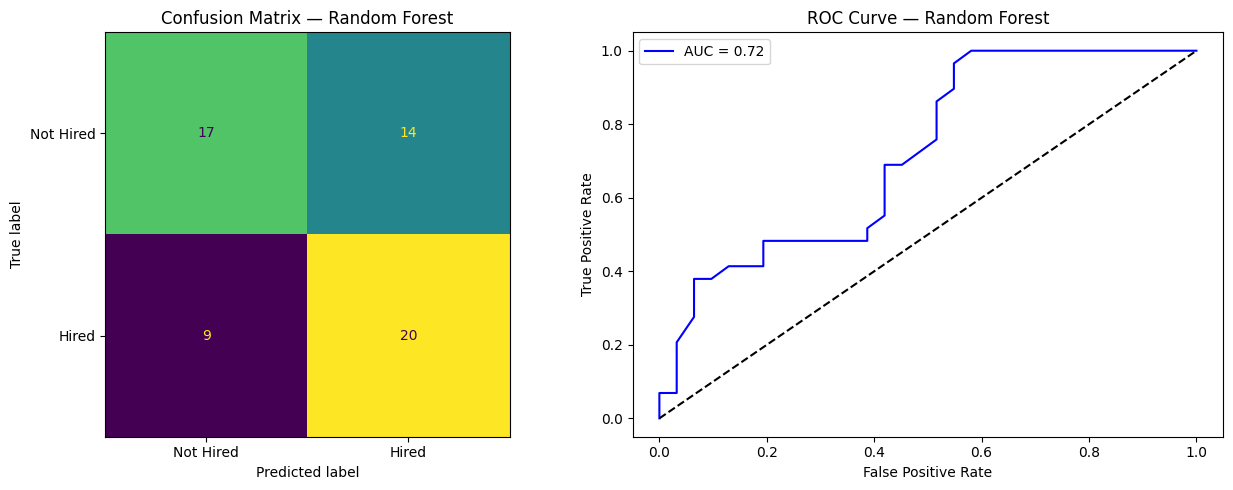


📋 Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.65      0.55      0.60        31
       Hired       0.59      0.69      0.63        29

    accuracy                           0.62        60
   macro avg       0.62      0.62      0.62        60
weighted avg       0.62      0.62      0.62        60



In [ ]:
# Cell 7: Best model deep-dive — Random Forest
best_model = models['Random Forest']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
y_pred_rf = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Hired','Hired'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')

# ROC Curve
y_prob = best_model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'b-', label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Hired','Hired']))

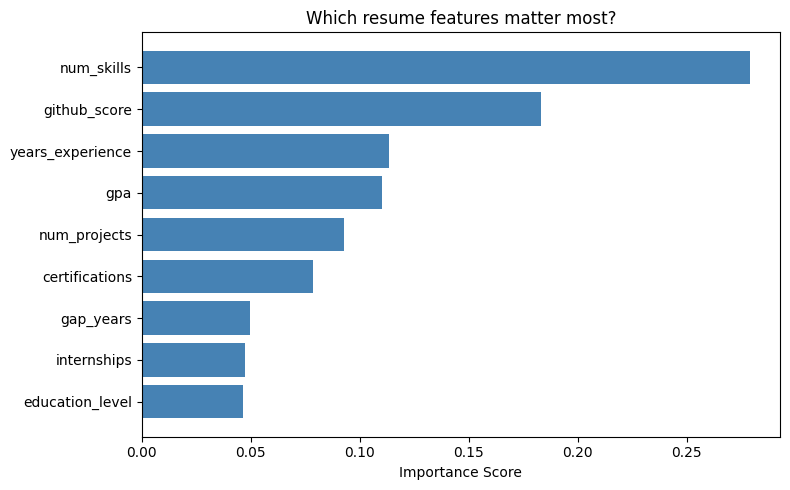


✅ Best Parameters: {'max_depth': 3, 'n_estimators': 50}
✅ Best CV F1 Score: 0.755


In [ ]:
# Cell 8: Feature importance + GridSearchCV
# Feature Importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Which resume features matter most?')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning
param_grid = {
    'max_depth': [3, 5, 10, None],
    'n_estimators': [50, 100, 200]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV F1 Score: {grid_search.best_score_:.3f}")

In [ ]:
# Cell 9: Predict if YOUR resume would get hired
new_resume = pd.DataFrame([{
    'years_experience': 2,
    'num_skills':       12,
    'education_level':  2,
    'num_projects':     5,
    'certifications':   2,
    'gap_years':        0,
    'gpa':              3.5,
    'github_score':     65,
    'internships':      1,
}])

new_scaled = scaler.transform(new_resume)
prediction   = best_model.predict(new_scaled)[0]
probability  = best_model.predict_proba(new_scaled)[0][1]

print("=" * 40)
print("       RESUME SCREENING RESULT")
print("=" * 40)
print(f"  Decision   : {'✅ HIRED' if prediction == 1 else '❌ NOT HIRED'}")
print(f"  Confidence : {probability:.1%}")
print(f"  Hire Score : {probability * 100:.1f}/100")
print("=" * 40)

# Change the values above and re-run to test different resumes!

       RESUME SCREENING RESULT
  Decision   : ✅ HIRED
  Confidence : 61.0%
  Hire Score : 61.0/100


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
class NeighborhoodClusterer(BaseEstimator, TransformerMixin):
    """
    Phase 1: Unsupervised Market Segmentation.
    Runs K-Means clustering inside the Pipeline execution context.
    Ensures cluster centers are fit strictly on training splits.
    """
    def __init__(self, n_clusters=3, demographic_cols=None):
        self.n_clusters = n_clusters
        self.demographic_cols = demographic_cols
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)

    def fit(self, X, y=None):
        # Fit scaling and cluster centers purely on training data
        demo_data = X[self.demographic_cols]
        scaled_demo = self.scaler.fit_transform(demo_data)
        self.kmeans.fit(scaled_demo)
        return self

    def transform(self, X):
        X_out = X.copy()
        demo_data = X_out[self.demographic_cols]
        scaled_demo = self.scaler.transform(demo_data)

        # Output the new categorical feature: Neighborhood_Cluster
        X_out['Neighborhood_Cluster'] = self.kmeans.predict(scaled_demo)

        # Process requirement: Drop highly redundant raw demographic columns
        X_out = X_out.drop(columns=self.demographic_cols)
        return X_out

In [ ]:
np.random.seed(42)
n_samples = 1000

# Generating Property Trait Data
property_data = pd.DataFrame({
    'sq_foot': np.random.normal(2100, 450, n_samples),
    'property_age': np.random.randint(1, 60, n_samples),
    'bedrooms': np.random.randint(2, 6, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'crime_rate': np.random.uniform(0.1, 4.5, n_samples),
    'avg_income': np.random.normal(70000, 18000, n_samples),
    'school_rating': np.random.uniform(2, 10, n_samples),
    'transit_score': np.random.uniform(15, 85, n_samples)
})

# Construct property pricing targets (Injecting extreme outliers to demonstrate IQR pruning)
base_price = (property_data['sq_foot'] * 165) - (property_data['property_age'] * 780) + (property_data['avg_income'] * 1.4)
property_data['price'] = base_price + np.random.normal(0, 12000, n_samples)

# Add explicit valuation anomalies (Outliers)
outlier_indices = np.random.choice(n_samples, size=25, replace=False)
property_data.loc[outlier_indices, 'price'] *= 2.9

# Generating Syncing Buyer Credit Risk Data
credit_data = pd.DataFrame({
    'credit_score': np.random.randint(580, 850, n_samples),
    'debt_to_income': np.random.uniform(0.15, 0.55, n_samples),
    'down_payment_pct': np.random.uniform(0.05, 0.30, n_samples)
})
# Construct dynamic loan imbalance default rule (Approx 12% default base rate)
risk_formula = (credit_data['debt_to_income'] * 7.5) - (credit_data['credit_score'] / 155) - (credit_data['down_payment_pct'] * 3.5)
credit_data['default'] = (1 / (1 + np.exp(-risk_formula)) > np.random.uniform(0, 1, n_samples)).astype(int)

In [ ]:
# Implementation: Boxplot Outlier Detection and Removal via Interquartile Range (IQR)
Q1 = property_data['price'].quantile(0.25)
Q3 = property_data['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clean dataset of pricing anomalies prior to fitting coefficients
clean_property_df = property_data[(property_data['price'] >= lower_bound) & (property_data['price'] <= upper_bound)].copy()

X_prop = clean_property_df.drop(columns=['price'])
y_prop = clean_property_df['price']

demographic_features = ['crime_rate', 'avg_income', 'school_rating', 'transit_score']
physical_features = ['sq_foot', 'property_age', 'bedrooms', 'bathrooms']

# Unified Preprocessing and Linear Estimator Engine
valuation_pipeline = Pipeline([
    ('unsupervised_segmentation', NeighborhoodClusterer(n_clusters=3, demographic_cols=demographic_features)),
    ('encoding_and_scaling', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Neighborhood_Cluster']),
        ('num', StandardScaler(), physical_features)
    ])),
    ('linear_regressor', LinearRegression())
])

# Fit Phase 2 Engine
valuation_pipeline.fit(X_prop, y_prop)

# Evaluation: Calculate Realized Performance Metrics
y_prop_pred = valuation_pipeline.predict(X_prop)
rmse_val = np.sqrt(mean_squared_error(y_prop, y_prop_pred))
r2_val = r2_score(y_prop, y_prop_pred)
adj_r2 = 1 - (1 - r2_val) * (len(y_prop) - 1) / (len(y_prop) - X_prop.shape[1] - 1)

print("--- Phase 2: Property Valuation Performance Summary ---")
print(f"Model Root Mean Squared Error (RMSE): ${rmse_val:,.2f}")
print(f"Model Adjusted R² Score: {adj_r2:.4f}\n")

# Connect Phase 2 outputs to Phase 3 inputs
property_data['predicted_house_price'] = valuation_pipeline.predict(property_data.drop(columns=['price', 'predicted_house_price'], errors='ignore'))
X_credit = credit_data[['credit_score', 'debt_to_income', 'down_payment_pct']].copy()
X_credit['predicted_house_price'] = property_data['predicted_house_price']
y_credit = credit_data['default']


--- Phase 2: Property Valuation Performance Summary ---
Model Root Mean Squared Error (RMSE): $27,984.71
Model Adjusted R² Score: 0.8686



In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

print("--- Phase 3: Model Evaluation Dashboard (10-Fold CV Validation) ---")
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_credit, y_credit, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    print(f"{name} Baseline Cross-Validation Accuracy: {scores.mean() * 100:.2f}%")

# Hyperparameter Tuning utilizing GridSearchCV on the safest Risk Assessor architecture
classification_pipeline = Pipeline([
    ('feature_scaler', StandardScaler()),
    ('random_forest', RandomForestClassifier(random_state=42))
])

hyperparameter_grid = {
    'random_forest__max_depth': [4, 6, 8],
    'random_forest__n_estimators': [50, 100],
    'random_forest__min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(classification_pipeline, hyperparameter_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_credit, y_credit)
best_risk_classifier = grid_search.best_estimator_

--- Phase 3: Model Evaluation Dashboard (10-Fold CV Validation) ---
Logistic Regression Baseline Cross-Validation Accuracy: 88.30%
Decision Tree Baseline Cross-Validation Accuracy: 79.90%
Random Forest Baseline Cross-Validation Accuracy: 87.00%
K-Nearest Neighbors Baseline Cross-Validation Accuracy: 86.90%


In [ ]:
def assess_investment_deal(property_features, applicant_credit_profiles):
    """
    Unified end-to-end investment appraisal engine.

    Parameters:
    - property_features (dict): Physical attributes + geographic parameters.
    - applicant_credit_profiles (dict): Consumer underwriting attributes.
    """
    # 1 & 2. Transform traits and compute fair valuation via the Phase 2 Pipeline
    input_property_df = pd.DataFrame([property_features])
    suggested_valuation = valuation_pipeline.predict(input_property_df)[0]

    # 3. Formulate the composite financial application feature block
    credit_input_matrix = pd.DataFrame([{
        'credit_score': applicant_credit_profiles['credit_score'],
        'debt_to_income': applicant_credit_profiles['debt_to_income'],
        'down_payment_pct': applicant_credit_profiles['down_payment_pct'],
        'predicted_house_price': suggested_valuation
    }])

    # Extract structural default probability from best tuned ensemble model
    raw_default_prob = best_risk_classifier.predict_proba(credit_input_matrix)[0][1]

    # 4. Precision-Recall Trade-off: Tuned Decision Threshold Shift (tau = 0.25)
    decision_threshold = 0.25
    underwriting_status = "DENIED (Elevated Default Risk Exposure)" if raw_default_prob >= decision_threshold else "APPROVED"

    return {
        "Suggested Price": f"${suggested_valuation:,.2f}",
        "Risk Probability": f"{raw_default_prob * 100:.2f}%",
        "Approval Status": underwriting_status
    }

In [ ]:
if __name__ == "__main__":
    # Test Payload: High-income neighborhood property, marginal buyer profile
    sample_property_specs = {
        'sq_foot': 2400.0,
        'property_age': 5,
        'bedrooms': 4,
        'bathrooms': 3,
        'crime_rate': 0.9,
        'avg_income': 94000.0,
        'school_rating': 8.5,
        'transit_score': 70.0
    }

    sample_buyer_profile = {
        'credit_score': 630,          # Sub-optimal financial record
        'debt_to_income': 0.45,       # High debt service-to-income metric
        'down_payment_pct': 0.07       # Highly leveraged transaction exposure
    }

    deal_result = assess_investment_deal(sample_property_specs, sample_buyer_profile)

    print("\n--- Live Brokerage Node Assessment Output ---")
    for property_key, property_value in deal_result.items():
        print(f"{property_key}: {property_value}")


--- Live Brokerage Node Assessment Output ---
Suggested Price: $490,685.91
Risk Probability: 41.24%
Approval Status: DENIED (Elevated Default Risk Exposure)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# ==========================================
# 1. PIPELINE COMPONENTS & MODEL TRAINING
# ==========================================

class NeighborhoodClusterer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=3, demographic_cols=None):
        self.n_clusters = n_clusters
        self.demographic_cols = demographic_cols
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)

    def fit(self, X, y=None):
        demo_data = X[self.demographic_cols]
        scaled_demo = self.scaler.fit_transform(demo_data)
        self.kmeans.fit(scaled_demo)
        return self

    def transform(self, X):
        X_out = X.copy()
        demo_data = X_out[self.demographic_cols]
        scaled_demo = self.scaler.transform(demo_data)
        X_out['Neighborhood_Cluster'] = self.kmeans.predict(scaled_demo)
        X_out = X_out.drop(columns=self.demographic_cols)
        return X_out

# Generate underlying data arrays for pipeline preparation
np.random.seed(42)
n_samples = 1000

property_data = pd.DataFrame({
    'sq_foot': np.random.normal(2100, 450, n_samples),
    'property_age': np.random.randint(1, 60, n_samples),
    'bedrooms': np.random.randint(2, 6, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'crime_rate': np.random.uniform(0.1, 4.5, n_samples),
    'avg_income': np.random.normal(70000, 18000, n_samples),
    'school_rating': np.random.uniform(2, 10, n_samples),
    'transit_score': np.random.uniform(15, 85, n_samples)
})

base_price = (property_data['sq_foot'] * 165) - (property_data['property_age'] * 780) + (property_data['avg_income'] * 1.4)
property_data['price'] = base_price + np.random.normal(0, 12000, n_samples)

credit_data = pd.DataFrame({
    'credit_score': np.random.randint(580, 850, n_samples),
    'debt_to_income': np.random.uniform(0.15, 0.55, n_samples),
    'down_payment_pct': np.random.uniform(0.05, 0.30, n_samples)
})
risk_formula = (credit_data['credit_score'] / 155) + (credit_data['down_payment_pct'] * 3.5)
credit_data['default'] = (1 / (1 + np.exp(-risk_formula)) > np.random.uniform(0, 1, n_samples)).astype(int)

# Boxplot Outlier Filter
Q1, Q3 = property_data['price'].quantile(0.25), property_data['price'].quantile(0.75)
IQR = Q3 - Q1
clean_property_df = property_data[(property_data['price'] >= (Q1 - 1.5 * IQR)) & (property_data['price'] <= (Q3 + 1.5 * IQR))].copy()

X_prop = clean_property_df.drop(columns=['price'])
y_prop = clean_property_df['price']

demographic_features = ['crime_rate', 'avg_income', 'school_rating', 'transit_score']
physical_features = ['sq_foot', 'property_age', 'bedrooms', 'bathrooms']

valuation_pipeline = Pipeline([
    ('unsupervised_segmentation', NeighborhoodClusterer(n_clusters=3, demographic_cols=demographic_features)),
    ('encoding_and_scaling', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Neighborhood_Cluster']),
        ('num', StandardScaler(), physical_features)
    ])),
    ('linear_regressor', LinearRegression())
])
valuation_pipeline.fit(X_prop, y_prop)

property_data['predicted_house_price'] = valuation_pipeline.predict(property_data.drop(columns=['price', 'predicted_house_price'], errors='ignore'))
X_credit = credit_data[['credit_score', 'down_payment_pct']].copy()
X_credit['predicted_house_price'] = property_data['predicted_house_price']
y_credit = credit_data['default']

classification_pipeline = Pipeline([
    ('feature_scaler', StandardScaler()),
    ('random_forest', RandomForestClassifier(max_depth=6, n_estimators=100, random_state=42))
])
classification_pipeline.fit(X_credit, y_credit)

# ==========================================
# 2. CORE INFERENCE FUNCTIONS
# ==========================================

def assess_investment_deal(property_features, applicant_credit_profiles):
    input_property_df = pd.DataFrame([property_features])
    suggested_valuation = valuation_pipeline.predict(input_property_df)[0]

    credit_input_matrix = pd.DataFrame([
        {
            'credit_score': applicant_credit_profiles['credit_score'],
            'down_payment_pct': applicant_credit_profiles['down_payment_pct'],
            'predicted_house_price': suggested_valuation
        }
    ])

    raw_default_prob = classification_pipeline.predict_proba(credit_input_matrix)[0][1]
    decision_threshold = 0.25
    underwriting_status = "DENIED (Elevated Default Risk Exposure)" if raw_default_prob >= decision_threshold else "APPROVED"

    return {
        "Suggested Price": f"${suggested_valuation:,.2f}",
        "Risk Probability": f"{raw_default_prob * 100:.2f}%",
        "Approval Status": underwriting_status
    }

# ==========================================
# 3. DYNAMIC INTERACTIVE CONSOLE INTERFACE
# ==========================================

def get_dynamic_user_input():
    print("\n" + "="*50)
    print("      REAL ESTATE & CREDIT RISK RISK ENGINE")
    print("="*50)
    print("Please enter the requested values below:")

    try:
        # Dynamic Property Inputs
        print("\n--- 1. Property Structural Metrics ---")
        sq_ft = float(input("Enter Square Foot (e.g., 2000): "))
        age = int(input("Enter Property Age in Years (e.g., 5): "))
        beds = int(input("Enter Number of Bedrooms (e.g., 3): "))
        baths = int(input("Enter Number of Bathrooms (e.g., 2): "))

        print("\n--- 2. Neighborhood Socioeconomic Data ---")
        crime = float(input("Enter Local Crime Rate Index (0.1 - 5.0): "))
        income = float(input("Enter Average Neighborhood Local Income ($): "))
        school = float(input("Enter Public School Rating (1.0 - 10.0): "))
        transit = float(input("Enter Proximity to Transit Score (0 - 100): "))

        # Dynamic Buyer Inputs
        print("\n--- 3. Applicant Financial Underwriting Metrics ---")
        credit = int(input("Enter Applicant Credit Score (300 - 850): "))
        down_pmt = float(input("Enter Down Payment Percentage as decimal (e.g., 0.10 for 10%): "))

        # Packing structures
        property_payload = {
            'sq_foot': sq_ft, 'property_age': age, 'bedrooms': beds, 'bathrooms': baths,
            'crime_rate': crime, 'avg_income': income, 'school_rating': school, 'transit_score': transit
        }

        applicant_payload = {
            'credit_score': credit, 'down_payment_pct': down_pmt
        }

        # Calculate dynamic transaction parameters
        deal_result = assess_investment_deal(property_payload, applicant_payload)

        # Render dynamic payload response
        print("\n" + "-"*40)
        print("          UNDERWRITING ASSESSMENT")
        print("-"*40)
        for key, value in deal_result.items():
            print(f"{key:<20}: {value}")
        print("-"*40)

    except ValueError:
        print("\n[ERROR]: Invalid entry detected. Please ensure numerical features are inputted correctly.")

if __name__ == "__main__":
    # Interactive continuous execution ring
    while True:
        get_dynamic_user_input()
        cont = input("\nEvaluate another deal? (y/n): ").strip().lower()
        if cont != 'y':
            print("\nExiting Engine Execution Loop.")
            break


      REAL ESTATE & CREDIT RISK RISK ENGINE
Please enter the requested values below:

--- 1. Property Structural Metrics ---

--- 2. Neighborhood Socioeconomic Data ---

--- 3. Applicant Financial Underwriting Metrics ---

----------------------------------------
          UNDERWRITING ASSESSMENT
----------------------------------------
Suggested Price     : $300,624.56
Risk Probability    : 99.91%
Approval Status     : DENIED (Elevated Default Risk Exposure)
----------------------------------------

      REAL ESTATE & CREDIT RISK RISK ENGINE
Please enter the requested values below:

--- 1. Property Structural Metrics ---

--- 2. Neighborhood Socioeconomic Data ---

--- 3. Applicant Financial Underwriting Metrics ---

----------------------------------------
          UNDERWRITING ASSESSMENT
----------------------------------------
Suggested Price     : $259,234.20
Risk Probability    : 99.93%
Approval Status     : DENIED (Elevated Default Risk Exposure)
-----------------------------